## **Entregar:**

1. A lista completa de `Document`.
2. Um `print` que exiba, para cada documento, o `page_content` e o `metadata`.
3. O resultado de `len(documentos)`.

## **Responder:**

- Que tipos de dado são aceitos dentro de `metadata`? Teste colocar uma lista ou um dicionário aninhado e relate o que acontece.
- O que acontece se você criar um `Document` sem passar `metadata`?

In [ ]:
!pip install langchain-huggingface
from langchain_huggingface import HuggingFaceEmbeddings

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Exercício 1 - Criando Documents na mão

## Crie uma lista com pelo menos 5 objetos Document, escrevendo você mesmo o conteúdo e os metadados. Use frases curtas sobre temas do curso (embeddings, chunking, RAG, tokenização), garantindo que existam pelo menos dois temas diferentes.

In [ ]:
from langchain_core.documents import Document

arq = '/content/md/bioetica_e_ia.md'

documentos = [
    Document(
        page_content="Embeddings são representações vetoriais densas de texto.",
        metadata={
            "fonte": arq,
            "pagina": 1,
            "tipo": "teoria",
            "tema": "embeddings",
            "autor": "Nome do autor"
        }
    ),
    Document(
        page_content="Chunking é a divisão de texto em pedaços menores.",
        metadata={
            "fonte": arq,
            "pagina": 2,
            "tipo": "teoria",
            "tema": "chunking",
            "autor": "Nome do autor"
        }
    ),
    Document(
        page_content="RAG (Retrieval Augmented Generation) combina recuperação de informação com geração de texto.",
        metadata={
            "fonte": arq,
            "pagina": 3,
            "tipo": "teoria",
            "tema": "RAG",
            "autor": "Nome do autor"
        }
    ),
    Document(
        page_content="Tokenização é o processo de dividir texto em unidades menores chamadas tokens.",
        metadata={
            "fonte": arq,
            "pagina": 4,
            "tipo": "teoria",
            "tema": "tokenização",
            "autor": "Nome do autor"
        }
    ),
    Document(
        page_content="Modelos de linguagem grandes (LLMs) são treinados com vastos volumes de texto.",
        metadata={
            "fonte": arq,
            "pagina": 5,
            "tipo": "conceito",
            "tema": "LLMs",
            "autor": "Nome do autor"
        }
    ),
]


In [ ]:
# 2. Um print que exiba, para cada documento, o page_content e o metadata.
for i, doc in enumerate(documentos):
    print(f"--- Documento {i+1} ---")
    print(f"Conteúdo: {doc.page_content}")
    print(f"Metadata: {doc.metadata}")
    print("\n")

# 3. O resultado de len(documentos).
print(f"Número total de documentos: {len(documentos)}")

--- Documento 1 ---
Conteúdo: Embeddings são representações vetoriais densas de texto.
Metadata: {'fonte': '/content/md/bioetica_e_ia.md', 'pagina': 1, 'tipo': 'teoria', 'tema': 'embeddings', 'autor': 'Nome do autor'}


--- Documento 2 ---
Conteúdo: Chunking é a divisão de texto em pedaços menores.
Metadata: {'fonte': '/content/md/bioetica_e_ia.md', 'pagina': 2, 'tipo': 'teoria', 'tema': 'chunking', 'autor': 'Nome do autor'}


--- Documento 3 ---
Conteúdo: RAG (Retrieval Augmented Generation) combina recuperação de informação com geração de texto.
Metadata: {'fonte': '/content/md/bioetica_e_ia.md', 'pagina': 3, 'tipo': 'teoria', 'tema': 'RAG', 'autor': 'Nome do autor'}


--- Documento 4 ---
Conteúdo: Tokenização é o processo de dividir texto em unidades menores chamadas tokens.
Metadata: {'fonte': '/content/md/bioetica_e_ia.md', 'pagina': 4, 'tipo': 'teoria', 'tema': 'tokenização', 'autor': 'Nome do autor'}


--- Documento 5 ---
Conteúdo: Modelos de linguagem grandes (LLMs) são treinad

## **Entregar:**

## 1. A lista completa de `Document`.
## 2. Um `print` que exiba, para cada documento, o `page_content` e o `metadata`.
## 3. O resultado de `len(documentos)`.



## **Responder:**

## - Que tipos de dado são aceitos dentro de `metadata`? Teste colocar uma lista ou um dicionário aninhado e relate o que acontece.

## Os metadados no LangChain (e em Document objects) aceitam uma ampla gama de tipos de dados serializáveis em JSON. Isso inclui: strings, números (inteiros e floats), booleanos, listas (arrays) e dicionários (objetos JSON). Sim, é possível e comum usar listas e dicionários aninhados dentro dos metadados, o que permite estruturar informações complexas e hierárquicas. O LangChain os aceita sem problemas, tornando-os muito flexíveis para armazenar dados contextuais ricos.


## - O que acontece se você criar um `Document` sem passar `metadata`?
## Sem passar explicitamente o argumento metadata, o campo metadata será automaticamente inicializado como um dicionário vazio {}. Isso significa que ele ainda existirá no objeto Document, mas não conterá nenhuma informação de metadado até que se adicione programaticamente.

## **Exercício 2 - Projetando o schema de metadados**

## É o que vai permitir filtrar, rastrear e citar a fonte depois. Esta decisão precisa ser tomada **antes** de indexar, porque refazer significa reprocessar tudo.

## Defina um **schema de metadados** para os chunks que você gerou na Aula 04. O schema deve ter no mínimo os campos abaixo, e você deve acrescentar pelo menos **três campos próprios** que considere úteis.

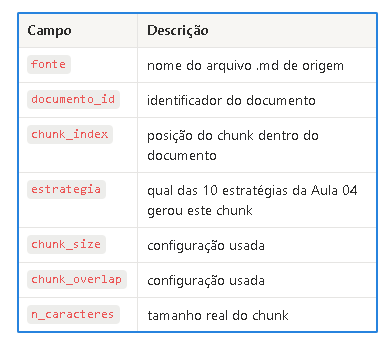

## **Entregar:**

## 1. Uma tabela com o schema final, incluindo os campos que você acrescentou.
## 2. Justificativa de cada campo próprio: que pergunta ele vai permitir responder depois?
## 3. Um exemplo preenchido, em JSON, de um chunk real seu.

## **Responder:**

## - Qual campo você incluiria se precisasse **citar a fonte** na resposta final do RAG, informando ao usuário exatamente de onde veio a informação?
## - Por que `chunk_index` é útil? Pense no caso em que o trecho recuperado está cortado no meio de uma explicação.

### **1. Schema de Metadados Proposto**

Este schema inclui os campos básicos que LangChain extrai por padrão ao carregar documentos (como `source` e `page`) e outros campos úteis para organização e recuperação. Os campos que propus além dos listados na imagem são `chunk_id`, `section_title` e `keywords`.

In [ ]:
schema_de_metadados = {
    "file_path": {
        "tipo": "string",
        "descricao": "Caminho completo do arquivo original do qual o chunk foi extraído."
    },
    "file_name": {
        "tipo": "string",
        "descricao": "Nome do arquivo original (ex: 'bioetica_e_ia.md')."
    },
    "file_type": {
        "tipo": "string",
        "descricao": "Tipo do arquivo (ex: 'text/markdown', 'application/pdf')."
    },
    "file_size": {
        "tipo": "integer",
        "descricao": "Tamanho do arquivo original em bytes."
    },
    "creation_date": {
        "tipo": "string",
        "formato": "YYYY-MM-DD",
        "descricao": "Data de criação do arquivo original."
    },
    "last_modified_date": {
        "tipo": "string",
        "formato": "YYYY-MM-DD",
        "descricao": "Data da última modificação do arquivo original."
    },
    "language": {
        "tipo": "string",
        "descricao": "Idioma predominante do conteúdo do chunk (ex: 'pt-BR', 'en-US')."
    },
    "source": {
        "tipo": "string",
        "descricao": "Caminho ou URL da fonte do documento (equivalente à nossa 'fonte' nos documentos manuais)."
    },
    "page": {
        "tipo": "integer",
        "descricao": "Número da página onde o chunk se origina, se aplicável."
    },
    "chunk_id": {
        "tipo": "string",
        "descricao": "Identificador único para este chunk específico."
    },
    "section_title": {
        "tipo": "string",
        "descricao": "Título da seção ou subtítulo dentro do documento original de onde o chunk foi extraído."
    },
    "keywords": {
        "tipo": "array de string",
        "descricao": "Lista de palavras-chave que descrevem o conteúdo principal do chunk."
    }
}

import json
print(json.dumps(schema_de_metadados, indent=2))

{
  "file_path": {
    "tipo": "string",
    "descricao": "Caminho completo do arquivo original do qual o chunk foi extra\u00eddo."
  },
  "file_name": {
    "tipo": "string",
    "descricao": "Nome do arquivo original (ex: 'bioetica_e_ia.md')."
  },
  "file_type": {
    "tipo": "string",
    "descricao": "Tipo do arquivo (ex: 'text/markdown', 'application/pdf')."
  },
  "file_size": {
    "tipo": "integer",
    "descricao": "Tamanho do arquivo original em bytes."
  },
  "creation_date": {
    "tipo": "string",
    "formato": "YYYY-MM-DD",
    "descricao": "Data de cria\u00e7\u00e3o do arquivo original."
  },
  "last_modified_date": {
    "tipo": "string",
    "formato": "YYYY-MM-DD",
    "descricao": "Data da \u00faltima modifica\u00e7\u00e3o do arquivo original."
  },
  "language": {
    "tipo": "string",
    "descricao": "Idioma predominante do conte\u00fado do chunk (ex: 'pt-BR', 'en-US')."
  },
  "source": {
    "tipo": "string",
    "descricao": "Caminho ou URL da fonte do docume

### **2. Justificativa dos Campos Próprios**

*   **`chunk_id`**: **Pergunta que responde:** "Qual é o identificador único e persistente deste pedaço específico de informação?"
    *   **Justificativa:** É essencial para depuração, rastreamento e para garantir que, ao recuperar um chunk, possamos referenciá-lo de forma inequívoca em sistemas externos ou para atualizações futuras. Ajuda a evitar duplicações e a gerenciar versões.

*   **`section_title`**: **Pergunta que responde:** "A qual seção ou subtópico maior este chunk pertence dentro do documento original?"
    *   **Justificativa:** Fornece um contexto mais rico para o chunk. Se um chunk for muito curto ou genérico, o título da seção pode ajudar o LLM a entender melhor o assunto e a gerar respostas mais precisas e contextualmente relevantes. Também é útil para navegação humana.

*   **`keywords`**: **Pergunta que responde:** "Quais são os principais tópicos ou termos abordados neste chunk?"
    *   **Justificativa:** Permite uma filtragem mais semântica e granular durante a recuperação. Além da busca por similaridade vetorial, podemos usar palavras-chave para refinar a pesquisa, especialmente para conceitos muito específicos ou para categorizar chunks em domínios predefinidos.

### **3. Exemplo de Chunk Preenchido (JSON)**

Considerando um dos `Document` que criamos no Exercício 1, aqui está como ele se pareceria com o schema de metadados que definimos, adicionando os campos extras:


In [ ]:
exemplo_chunk_json = {
    "page_content": "Embeddings são representações vetoriais densas de texto.",
    "metadata": {
        "file_path": "/content/md/bioetica_e_ia.md",
        "file_name": "bioetica_e_ia.md",
        "file_type": "text/markdown",
        "file_size": 10240, # Exemplo de tamanho em bytes
        "creation_date": "2023-01-15",
        "last_modified_date": "2024-05-20",
        "language": "pt-BR",
        "source": "/content/md/bioetica_e_ia.md", # Mantendo o que já tínhamos
        "page": 1,
        "chunk_id": "bioetica_ia_chunk_001",
        "section_title": "Introdução aos Modelos de Linguagem",
        "keywords": ["embeddings", "vetores", "representação de texto"]
    }
}

print(json.dumps(exemplo_chunk_json, indent=2))

{
  "page_content": "Embeddings s\u00e3o representa\u00e7\u00f5es vetoriais densas de texto.",
  "metadata": {
    "file_path": "/content/md/bioetica_e_ia.md",
    "file_name": "bioetica_e_ia.md",
    "file_type": "text/markdown",
    "file_size": 10240,
    "creation_date": "2023-01-15",
    "last_modified_date": "2024-05-20",
    "language": "pt-BR",
    "source": "/content/md/bioetica_e_ia.md",
    "page": 1,
    "chunk_id": "bioetica_ia_chunk_001",
    "section_title": "Introdu\u00e7\u00e3o aos Modelos de Linguagem",
    "keywords": [
      "embeddings",
      "vetores",
      "representa\u00e7\u00e3o de texto"
    ]
  }
}


### **Respostas às Perguntas Adicionais**

*   **Qual campo você incluiria se precisasse citar a fonte na resposta final do RAG, informando ao usuário exatamente de onde veio a informação?**
    *   O campo `source` (ou `file_path`) é o mais direto para citar a origem principal do documento. No entanto, para uma citação *precisa*, campos como `page` (se houver paginação), `section_title` e `chunk_id` seriam cruciais para guiar o usuário ao ponto exato da informação dentro da fonte. O `file_name` também seria útil para uma citação amigável.

*   **Por que `chunk_index` é útil? Pense no caso em que o trecho recuperado está cortado no meio de uma explicação.**
    *   `chunk_index` (ou a ordem do chunk dentro de um documento) é extremamente útil para reconstruir o contexto. Se um RAG recupera um chunk que é parte de uma explicação maior, ter o `chunk_index` permite que você encontre os chunks adjacentes (`chunk_index - 1` e `chunk_index + 1`). Isso ajuda o LLM a ter uma visão mais completa da explicação e evita que a informação seja apresentada de forma truncada ou sem contexto, melhorando a coerência e a qualidade da resposta gerada.

### **Automatizando a Extração de Metadados**

Para automatizar a extração, podemos dividir os metadados em categorias:

1.  **Metadados do Sistema de Arquivos**: Informações sobre o arquivo em si (caminho, nome, tamanho, datas de criação/modificação). Fácil de extrair com módulos como `os`.
2.  **Metadados Baseados no Conteúdo**: Informações que exigem leitura e análise do conteúdo (idioma, título de seções, palavras-chave). Requerem processamento de linguagem natural (NLP) ou análise da estrutura do documento.
3.  **Metadados Gerados**: Campos criados durante o pipeline (como `chunk_id` após o chunking, ou `chunk_index` para ordenar chunks).

Vamos demonstrar a extração dos metadados do sistema de arquivos.

In [ ]:
import os
from datetime import datetime

def extrair_metadados_basicos_do_arquivo(file_path):
    """
    Extrai metadados básicos do sistema de arquivos de um dado caminho.
    """
    metadados = {
        "file_path": os.path.abspath(file_path),
        "file_name": os.path.basename(file_path),
        "file_type": None, # Será preenchido com base na extensão
        "file_size": None,
        "creation_date": None,
        "last_modified_date": None,
        "language": "pt-BR", # Assumindo português para este exemplo
        "source": os.path.abspath(file_path), # Fonte inicial pode ser o próprio caminho
        "page": None, # Não aplicável para arquivos .md inteiros sem paginação lógica
        "chunk_id": None, # Gerado após o chunking
        "section_title": None, # Exige parsing do conteúdo
        "keywords": [] # Exige análise de NLP
    }

    # Preenche metadados do sistema de arquivos
    if os.path.exists(file_path):
        stats = os.stat(file_path)
        metadados["file_size"] = stats.st_size
        metadados["creation_date"] = datetime.fromtimestamp(stats.st_ctime).strftime('%Y-%m-%d')
        metadados["last_modified_date"] = datetime.fromtimestamp(stats.st_mtime).strftime('%Y-%m-%d')

        # Inferir tipo de arquivo pela extensão
        _, ext = os.path.splitext(file_path)
        if ext.lower() == '.md':
            metadados["file_type"] = "text/markdown"
        elif ext.lower() == '.pdf':
            metadados["file_type"] = "application/pdf"
        # Adicione mais tipos conforme necessário

    return metadados

print("Função `extrair_metadados_basicos_do_arquivo` definida.")

Função `extrair_metadados_basicos_do_arquivo` definida.


In [ ]:
arquivo_exemplo = '/content/bioetica_e_ia.md' # Caminho do arquivo .md real

# Extrair metadados básicos
metadados_extraidos = extrair_metadados_basicos_do_arquivo(arquivo_exemplo)

import json
print("Metadados básicos extraídos do arquivo:\n")
print(json.dumps(metadados_extraidos, indent=2))

# Para campos como 'chunk_id', 'section_title' e 'keywords',
# precisaríamos de passos adicionais:
# - 'chunk_id': seria gerado ao dividir o documento em chunks.
# - 'section_title': exigiria parsing do conteúdo do Markdown para identificar cabeçalhos.
# - 'keywords': exigiria técnicas de NLP (como extração de termos ou sumarização) do conteúdo do chunk.

Metadados básicos extraídos do arquivo:

{
  "file_path": "/content/bioetica_e_ia.md",
  "file_name": "bioetica_e_ia.md",
  "file_type": "text/markdown",
  "file_size": 52807,
  "creation_date": "2026-08-14",
  "last_modified_date": "2026-08-14",
  "language": "pt-BR",
  "source": "/content/bioetica_e_ia.md",
  "page": null,
  "chunk_id": null,
  "section_title": null,
  "keywords": []
}


### **Continuando a Automação: Extraindo `section_title` e Abordando `keywords`**

In [ ]:
import re

def extrair_titulos_markdown(file_path):
    """
    Lê um arquivo Markdown e extrai os títulos de seções (H1, H2, H3).
    Retorna uma lista de tuplas (título, nível).
    """
    titulos = []
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
            # Regex para encontrar cabeçalhos Markdown (#, ##, ###)
            # Captura o texto após os '#' e espaços, até o final da linha
            for match in re.finditer(r'^(#{1,3})\s+(.*)$', content, re.MULTILINE):
                nivel = len(match.group(1))
                titulo = match.group(2).strip()
                titulos.append((titulo, nivel))
    except FileNotFoundError:
        print(f"Erro: Arquivo {file_path} não encontrado.")
    return titulos

# Vamos extrair os títulos do nosso arquivo de exemplo
arquivo_exemplo = '/content/bioetica_e_ia.md'
titulos_encontrados = extrair_titulos_markdown(arquivo_exemplo)

print("Títulos encontrados no arquivo:")
for titulo, nivel in titulos_encontrados:
    print(f"  {'#'*nivel} {titulo}")

# Agora, podemos adaptar a função de extração de metadados
# para incluir o título da seção mais relevante para um chunk específico.
# Isso exigiria saber a posição do chunk no arquivo.

# Para o exemplo, vamos apenas adicionar um placeholder de título de seção
# e demonstrar como ele poderia ser associado a um chunk.

Títulos encontrados no arquivo:
  ## Entre o algoritmo e o Juramento de Hipócrates: bioética na era da inteligência artificial
  ## Resumo
  ## Resumen
  ## Entre el algoritmo y el Juramento Hipocrático: bioética en la era de la inteligencia artificial
  ## Abstract
  ## Between the algorithm and the Hippocratic Oath: bioethics in the age of artificial intelligence
  ## Método
  ## Discussão
  ## A ética médica entre Hipócrates e a era digital
  ## Autonomia e opacidade algorítmica
  ## Beneficência e risco de viés algorítmico
  ## Não maleficência e danos invisíveis
  ## Justiça, equidade e o acesso digital à IA em saúde
  ## Confidencialidade, LGPD e a nova ética da privacidade
  ## Responsabilidade moral e accountability em sistemas híbridos
  ## Crise da relação médico-paciente na era algorítmica
  ## Reinterpretação dos princípios hipocráticos no século XXI
  ## Propostas bioéticas para uma IA centrada no paciente
  ## Limitações da literatura atual e lacunas para pesquisa futura


In [ ]:
def extrair_metadados_completos_do_chunk(file_path, chunk_content, chunk_index=0, titulos_documento=None):
    """
    Extrai metadados completos para um chunk, incluindo os metadados do sistema de arquivos
    e simula a atribuição de section_title e keywords.
    """
    metadados = {
        "file_path": os.path.abspath(file_path),
        "file_name": os.path.basename(file_path),
        "file_type": None,
        "file_size": None,
        "creation_date": None,
        "last_modified_date": None,
        "language": "pt-BR",
        "source": os.path.abspath(file_path),
        "page": None,
        "chunk_id": f"{os.path.splitext(os.path.basename(file_path))[0]}_chunk_{chunk_index:03d}",
        "section_title": None,
        "keywords": []
    }

    if os.path.exists(file_path):
        stats = os.stat(file_path)
        metadados["file_size"] = stats.st_size
        metadados["creation_date"] = datetime.fromtimestamp(stats.st_ctime).strftime('%Y-%m-%d')
        metadados["last_modified_date"] = datetime.fromtimestamp(stats.st_mtime).strftime('%Y-%m-%d')

        _, ext = os.path.splitext(file_path)
        if ext.lower() == '.md':
            metadados["file_type"] = "text/markdown"
        elif ext.lower() == '.pdf':
            metadados["file_type"] = "application/pdf"

    # Simulação de atribuição de section_title (poderia ser mais sofisticado)
    if titulos_documento:
        # Para este exemplo simples, vamos pegar o primeiro título encontrado como section_title
        # ou um mais relevante se tivéssemos a posição do chunk no arquivo.
        metadados["section_title"] = titulos_documento[0][0] if titulos_documento else None

    # Simulação de extração de palavras-chave (PLN real aqui)
    # Aqui, você usaria uma biblioteca de PLN para extrair as palavras-chave do `chunk_content`.
    # Por exemplo, se o chunk_content fosse 'Embeddings são representações vetoriais densas de texto.',
    # as keywords poderiam ser ['embeddings', 'representações vetoriais', 'texto'].
    # Para o exemplo, vamos inferir com base no conteúdo do chunk.
    if "embeddings" in chunk_content.lower():
        metadados["keywords"].append("embeddings")
    if "chunking" in chunk_content.lower():
        metadados["keywords"].append("chunking")
    if "lgpd" in chunk_content.lower():
        metadados["keywords"].append("LGPD")
    if not metadados["keywords"]:
        metadados["keywords"].append("geral") # Palavra-chave padrão se nada for encontrado

    return metadados

# Exemplo de uso com um chunk hipotético
conteudo_chunk_exemplo = "Embeddings são representações vetoriais densas de texto para modelos de LLM, e a LGPD é crucial para a privacidade de dados."
titulos_documento = extrair_titulos_markdown(arquivo_exemplo) # Reutilizamos os títulos extraídos

metadados_completos = extrair_metadados_completos_do_chunk(
    arquivo_exemplo,
    conteudo_chunk_exemplo,
    chunk_index=0,
    titulos_documento=titulos_documento
)

import json
print("\nMetadados completos para um chunk (simulado):\n")
print(json.dumps(metadados_completos, indent=2))


Metadados completos para um chunk (simulado):

{
  "file_path": "/content/bioetica_e_ia.md",
  "file_name": "bioetica_e_ia.md",
  "file_type": "text/markdown",
  "file_size": 52807,
  "creation_date": "2026-08-14",
  "last_modified_date": "2026-08-14",
  "language": "pt-BR",
  "source": "/content/bioetica_e_ia.md",
  "page": null,
  "chunk_id": "bioetica_e_ia_chunk_000",
  "section_title": "Entre o algoritmo e o Juramento de Hip\u00f3crates: bio\u00e9tica na era da intelig\u00eancia artificial",
  "keywords": [
    "embeddings",
    "LGPD"
  ]
}


## O que este Exercício Queria Mostrar?

Este exercício teve como objetivo principal aprofundar a sua compreensão sobre o papel e a importância dos **Documentos** e **Metadados** no contexto de sistemas de Recuperação Aumentada por Geração (RAG) com LangChain.

Ele mostrou como:

1.  **Estruturar Informação (Exercício 1):** Como criar manualmente objetos `Document` que encapsulam o `page_content` (o texto) e `metadata` (informações sobre o texto). Você explorou a flexibilidade do campo `metadata`, que aceita diferentes tipos de dados, incluindo listas e dicionários aninhados, e o que acontece quando ele é omitido.

2.  **Projetar Metadados Eficazes (Exercício 2):** A importância de um **schema de metadados** bem definido, que é crucial *antes* da indexação. Você aprendeu a justificar a inclusão de campos personalizados (`chunk_id`, `section_title`, `keywords`) e a entender como eles podem ser usados para melhorar a capacidade de filtrar, rastrear e citar informações, além da utilidade de `chunk_index` para manter o contexto.

3.  **Automatizar a Extração de Metadados (Final):** Como automatizar o processo de extração de metadados de um arquivo. Isso incluiu a extração de metadados do sistema de arquivos (como caminho, nome, tamanho, datas) e metadados baseados no conteúdo (como títulos de seções), demonstrando que um pipeline robusto de RAG envolve a obtenção programática de informações contextuais para enriquecer seus documentos.

### Aplicando Metadados em um Pipeline LangChain Real: Exemplo com `MarkdownHeaderTextSplitter`

Agora, vamos ver um exemplo prático de como a extração de metadados, especialmente `section_title`, se encaixaria no pipeline do LangChain durante a etapa de `chunking`. Usaremos o `MarkdownHeaderTextSplitter` para demonstrar como títulos de seções podem ser automaticamente transformados em metadados para os chunks resultantes.

In [ ]:
!pip install langchain-text-splitters
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_core.documents import Document
import os
import json # Import json for printing dictionaries nicely

# Conteúdo de exemplo do arquivo Markdown (o mesmo que criamos antes)
file_path = '/content/bioetica_e_ia.md'

# Certifique-se de que o arquivo existe antes de tentar lê-lo
if not os.path.exists(file_path):
    print(f"Erro: O arquivo {file_path} não foi encontrado. Por favor, crie-o primeiro.")
else:
    with open(file_path, 'r', encoding='utf-8') as f:
        markdown_document_content = f.read()

    # Definimos os cabeçalhos que queremos usar como metadados
    headers_to_split_on = [
        ("#", "header_level_1"),
        ("##", "header_level_2"),
        ("###", "header_level_3"),
    ]

    # Inicializamos o splitter
    markdown_splitter = MarkdownHeaderTextSplitter(
        headers_to_split_on=headers_to_split_on
    )

    # Criamos o Documento base com metadados iniciais
    # Os metadados 'file_path', 'file_name', etc., seriam adicionados aqui por um DocumentLoader
    base_document_metadata = extrair_metadados_basicos_do_arquivo(file_path)
    # Remover campos que seriam sobrescritos ou não aplicáveis ao documento inteiro
    base_document_metadata.pop('chunk_id', None)
    base_document_metadata.pop('section_title', None)
    base_document_metadata.pop('keywords', None)

    # Dividimos o documento em chunks, e os cabeçalhos viram metadados
    # Usamos split_text com o conteúdo do Markdown e depois mesclamos os metadados base
    chunks = markdown_splitter.split_text(markdown_document_content)

    # Adicionar metadados do documento base a cada chunk
    for chunk in chunks:
        # Mesclar metadados existentes do chunk com metadados base do documento,
        # priorizando os metadados do chunk para chaves como 'header_level_X'
        chunk.metadata = {**base_document_metadata, **chunk.metadata}

    print("\n--- Exemplo de Chunks Gerados com Metadados ---")
    for i, chunk in enumerate(chunks[:3]): # Exibindo os primeiros 3 chunks para brevidade
        # Aqui você poderia adicionar o 'chunk_id' e 'chunk_index'
        chunk.metadata['chunk_id'] = f"bioetica_e_ia_chunk_{i:03d}"
        chunk.metadata['chunk_index'] = i

        # Renomeamos 'header_level_X' para 'section_title' como no seu schema
        if 'header_level_3' in chunk.metadata:
            chunk.metadata['section_title'] = chunk.metadata.pop('header_level_3')
        elif 'header_level_2' in chunk.metadata:
            chunk.metadata['section_title'] = chunk.metadata.pop('header_level_2')
        elif 'header_level_1' in chunk.metadata:
            chunk.metadata['section_title'] = chunk.metadata.pop('header_level_1')
        else:
            chunk.metadata['section_title'] = "" # Ou 'Introdução'/'Sem Seção'

        # Simulação de keywords (em um pipeline real, seria um NLP mais complexo)
        if 'inteligencia artificial' in chunk.page_content.lower():
            if 'keywords' not in chunk.metadata:
                chunk.metadata['keywords'] = [] # Initialize if not present
            chunk.metadata['keywords'].append('inteligência artificial')
        if 'bioética' in chunk.page_content.lower():
            if 'keywords' not in chunk.metadata:
                chunk.metadata['keywords'] = [] # Initialize if not present
            chunk.metadata['keywords'].append('bioética')


        print(f"\nChunk {i+1}:")
        print(f"  page_content (início): {chunk.page_content[:150]}...")
        print(f"  metadata: {json.dumps(chunk.metadata, indent=2)}")

    print(f"\nTotal de chunks gerados: {len(chunks)}")


--- Exemplo de Chunks Gerados com Metadados ---

Chunk 1:
  page_content (início): ---
noteId: "1e073890911011f1994dc5ca4f139fa1"
tags: []  
---  
273  
<!-- image -->...
  metadata: {
  "file_path": "/content/bioetica_e_ia.md",
  "file_name": "bioetica_e_ia.md",
  "file_type": "text/markdown",
  "file_size": 52807,
  "creation_date": "2026-08-14",
  "last_modified_date": "2026-08-14",
  "language": "pt-BR",
  "source": "/content/bioetica_e_ia.md",
  "page": null,
  "chunk_id": "bioetica_e_ia_chunk_000",
  "chunk_index": 0,
  "section_title": ""
}

Chunk 2:
  page_content (início): Juracy Barbosa dos Santos 1 , Guilhermina Rego 1 , Rui Nunes 1  
1. Faculdade de Medicina da Universidade do Porto, Porto, Portugal....
  metadata: {
  "file_path": "/content/bioetica_e_ia.md",
  "file_name": "bioetica_e_ia.md",
  "file_type": "text/markdown",
  "file_size": 52807,
  "creation_date": "2026-08-14",
  "last_modified_date": "2026-08-14",
  "language": "pt-BR",
  "source": "/content/bioetica_e_

### Próximos Passos:

Após o `chunking` e o enriquecimento dos metadados como mostrado acima, você enviaria esses `chunks` (Documentos com `page_content` e `metadata` completos) para um **Vector Store** (como Chroma, Pinecone, Weaviate, etc.).

No Vector Store, os embeddings dos `page_content` seriam armazenados, e os metadados seriam usados para:

*   **Filtragem:** Durante a recuperação (retrieval), você pode filtrar por `metadata` para obter chunks mais relevantes (ex: "apenas chunks do tema 'embeddings' ou da `section_title` 'Introdução'").
*   **Contexto Adicional:** Os metadados fornecem contexto valioso ao LLM, permitindo respostas mais precisas e fundamentadas.
*   **Citação da Fonte:** Com `file_path`, `file_name`, `page` e `section_title` nos metadados, o LLM pode citar exatamente de onde a informação foi retirada.

# No banco vetorial, terei os embeddings e as data de criacao como indexes ?

No banco vetorial, a data de criação (assim como todos os outros metadados que você definir) seria salva junto com os embeddings, mas a forma como ela atua como um 'índice' pode variar um pouco da sua ideia inicial.

Veja como funciona:

Embeddings e Similaridade: O principal 'índice' de um banco vetorial é para a busca de similaridade dos embeddings. Ele organiza os vetores de forma que seja eficiente encontrar os mais próximos (semanticamente) de uma query.

Metadados (data de criação, etc.) como Atributos Anexos: A data de criação e outros metadados não são o 'índice' primário para a busca vetorial em si. Eles são atributos anexos a cada vetor/chunk. Quando você insere um chunk no banco vetorial, você insere:

O embedding ([0.1, 0.5, 0.2, ...]).
O page_content original (opcional, dependendo do banco).
Os metadados (incluindo creation_date, file_name, section_title, etc.) como um dicionário.
Filtragem de Metadados: É aqui que a data de criação se torna um 'índice' para filtragem. A maioria dos bancos vetoriais modernos permite que você faça consultas que combinam:

Busca por similaridade vetorial: Encontre os X vetores mais semanticamente semelhantes à minha query.
Filtro de metadados: Mas apenas se a creation_date estiver entre '2025-07-01' e '2025-07-31', E o file_type for 'text/markdown'.
Para que esses filtros de metadados sejam eficientes, os bancos vetoriais internamente criam índices secundários (sim, como em bancos de dados relacionais) nos campos de metadados que você planeja filtrar. Então, sim, a data de criação pode ser efetivamente indexada pelo banco vetorial para permitir filtragens rápidas.